In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
Lab7Tasks = jpype.JClass("utils.greedy_algorithms.Lab7Tasks")
Order = jpype.JClass("utils.greedy_algorithms.Lab7Tasks$Order")
Child = jpype.JClass("utils.greedy_algorithms.Lab7Tasks$Child")
MaxProfitScheduling = jpype.JClass("utils.greedy_algorithms.Lab7Tasks$MaxProfitScheduling")
ChildrenGrouping = jpype.JClass("utils.greedy_algorithms.Lab7Tasks$ChildrenGrouping")

ArrayList = jpype.JClass("java.util.ArrayList")

In [3]:
def generate_random_orders(n: int, max_deadline: int = 10, max_cost: int = 100) -> ArrayList:
    orders = ArrayList()
    for i in range(n):
        deadline = random.randint(1, max_deadline)
        cost = random.randint(1, max_cost)
        orders.add(Order(i + 1, deadline, cost))
    return orders

def generate_random_children(n: int, min_age: int = 3, max_age: int = 12) -> ArrayList:
    children = ArrayList()
    for i in range(n):
        age = random.randint(min_age, max_age)
        children.add(Child(i + 1, age))
    return children

def test_task1(n_values: List[int], iterations: int = 10):
    results = []
    
    for n in n_values:
        print(f"\nТестирование задачи 1 для n = {n}")
        times = []
        profits = []
        
        for _ in range(iterations):
            orders = generate_random_orders(n)
            algorithm = MaxProfitScheduling()
            result = algorithm.findMaxProfitSchedule(orders)
            
            times.append(result.executionTime)
            total_profit = sum(order.cost for order in result.result)
            profits.append(total_profit)
        
        results.append({
            'n': n,
            'mean_time': np.mean(times),
            'std_time': np.std(times),
            'mean_profit': np.mean(profits),
            'std_profit': np.std(profits)
        })
    
    return results

def test_task2(n_values: List[int], iterations: int = 10):
    results = []
    
    for n in n_values:
        print(f"\nТестирование задачи 2 для n = {n}")
        times = []
        group_counts = []
        
        for _ in range(iterations):
            children = generate_random_children(n)
            algorithm = ChildrenGrouping()
            result = algorithm.groupChildren(children)
            
            times.append(result.executionTime)
            group_counts.append(len(result.result))
        
        results.append({
            'n': n,
            'mean_time': np.mean(times),
            'std_time': np.std(times),
            'mean_groups': np.mean(group_counts),
            'std_groups': np.std(group_counts)
        })
    
    return results

def plot_results(results: List[dict], title: str, ylabel: str):
    n_values = [r['n'] for r in results]
    means = [r['mean_time'] for r in results]
    stds = [r['std_time'] for r in results]
    
    plt.figure(figsize=(10, 6))
    plt.errorbar(n_values, means, yerr=stds, fmt='o-')
    plt.xlabel('Количество элементов (n)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

def test_example_task1():
    # Пример из условия
    orders = ArrayList()
    orders.add(Order(1, 2, 40))  # A
    orders.add(Order(2, 1, 25))  # B
    orders.add(Order(3, 2, 30))  # C
    orders.add(Order(4, 1, 15))  # D
    orders.add(Order(5, 3, 20))  # E
    
    algorithm = MaxProfitScheduling()
    result = algorithm.findMaxProfitSchedule(orders)
    
    print("\nПример из условия (Задача 1):")
    print("Выбранные заказы:")
    total_profit = 0
    for order in result.result:
        print(f"Заказ {chr(64 + order.id)}: стоимость = {order.cost}, дедлайн = {order.deadline}")
        total_profit += order.cost
    print(f"Суммарная стоимость: {total_profit}")

def test_example_task2():
    # Пример для задачи 2
    children = ArrayList()
    children.add(Child(1, 5))
    children.add(Child(2, 6))
    children.add(Child(3, 3))
    children.add(Child(4, 7))
    children.add(Child(5, 4))
    children.add(Child(6, 8))
    
    algorithm = ChildrenGrouping()
    result = algorithm.groupChildren(children)
    
    print("\nПример группировки детей (Задача 2):")
    for i, group in enumerate(result.result, 1):
        print(f"Группа {i}:")
        for child in group:
            print(f"  Ребенок {child.id}: возраст = {child.age}")

def main():
    # Тестирование примеров из условия
    test_example_task1()
    test_example_task2()
    
    # Тестирование производительности
    n_values = [10, 100, 1000, 10000]
    
    print("\nТестирование задачи 1: Выбор заказов с максимальной суммарной стоимостью")
    task1_results = test_task1(n_values)
    plot_results(task1_results, 
                "Время выполнения задачи 1", 
                "Среднее время выполнения (нс)")
    
    print("\nТестирование задачи 2: Группировка детей по возрасту")
    task2_results = test_task2(n_values)
    plot_results(task2_results, 
                "Время выполнения задачи 2", 
                "Среднее время выполнения (нс)")
    
    # Вывод результатов в таблицы
    print("\nРезультаты задачи 1:")
    df1 = pd.DataFrame(task1_results)
    print(df1.to_string(index=False))
    
    print("\nРезультаты задачи 2:")
    df2 = pd.DataFrame(task2_results)
    print(df2.to_string(index=False))


Пример из условия (Задача 1):
Выбранные заказы:
Заказ A: стоимость = 40, дедлайн = 2
Заказ C: стоимость = 30, дедлайн = 2
Заказ E: стоимость = 20, дедлайн = 3
Суммарная стоимость: 90

Пример группировки детей (Задача 2):
Группа 1:
  Ребенок 3: возраст = 3
  Ребенок 5: возраст = 4
  Ребенок 1: возраст = 5
Группа 2:
  Ребенок 2: возраст = 6
  Ребенок 4: возраст = 7
  Ребенок 6: возраст = 8

Тестирование задачи 1: Выбор заказов с максимальной суммарной стоимостью

Тестирование задачи 1 для n = 10

Тестирование задачи 1 для n = 100

Тестирование задачи 1 для n = 1000

Тестирование задачи 1 для n = 10000


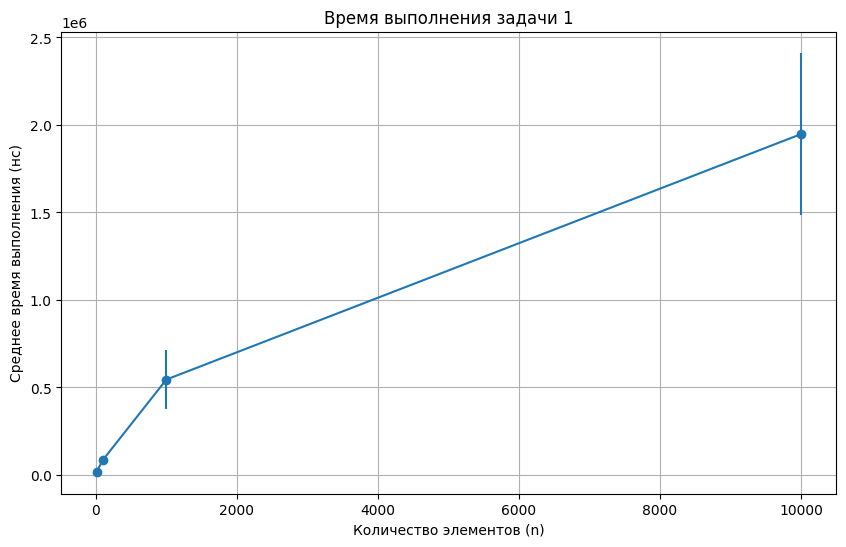


Тестирование задачи 2: Группировка детей по возрасту

Тестирование задачи 2 для n = 10

Тестирование задачи 2 для n = 100

Тестирование задачи 2 для n = 1000

Тестирование задачи 2 для n = 10000


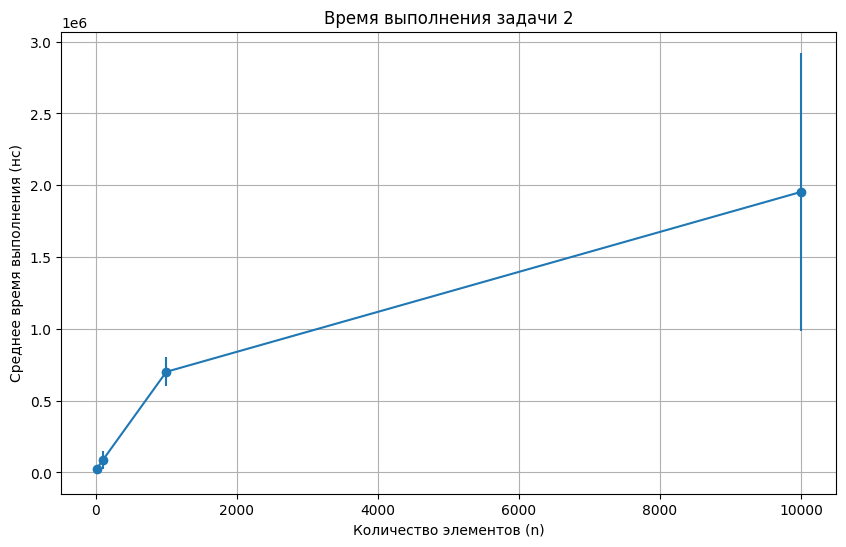


Результаты задачи 1:
    n  mean_time      std_time  mean_profit  std_profit
   10    16510.0   4187.946991        479.9   87.404176
  100    84920.0  20617.798137        951.0   14.919786
 1000   544670.0 169705.892944        998.3    1.552417
10000  1947600.0 465108.911977       1000.0    0.000000

Результаты задачи 2:
    n  mean_time      std_time  mean_groups  std_groups
   10    22710.0  24750.412118          3.0         0.0
  100    86400.0  64205.700681          4.0         0.0
 1000   700760.0 101496.947737          4.0         0.0
10000  1953560.0 969280.898605          4.0         0.0


In [4]:
main()